<a href="https://colab.research.google.com/github/Yashlad041/Edunet-Intership-tasks-/blob/main/day-6_11-07_2026-(Linear_Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Import Required Libraries

In [ ]:
# ===============================
# Import Required Libraries
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

Task 2: Load Dataset,Display Dataset

In [ ]:
# ===============================
# Load Dataset
# ===============================

df = pd.read_csv("/content/smart_grid_energy_demand.csv")

df.head()

,Timestamp,Hour_of_Day,Month,Is_Weekend,Temperature_C,Cloud_Cover_Percent,Energy_Demand_MW
0,2022-01-01 00:00:00,0,1,1,0.3,2.3,1041.6
1,2022-01-01 01:00:00,1,1,1,0.3,49.8,1133.0
2,2022-01-01 02:00:00,2,1,1,0.6,25.7,1118.7
3,2022-01-01 03:00:00,3,1,1,-0.4,67.9,1140.1
4,2022-01-01 04:00:00,4,1,1,1.3,13.5,1126.5


In [ ]:
print("First Five Rows")
print(df.head())

print("\nLast Five Rows")
print(df.tail())

First Five Rows
             Timestamp  Hour_of_Day  Month  Is_Weekend  Temperature_C  \
0  2022-01-01 00:00:00            0      1           1            0.3   
1  2022-01-01 01:00:00            1      1           1            0.3   
2  2022-01-01 02:00:00            2      1           1            0.6   
3  2022-01-01 03:00:00            3      1           1           -0.4   
4  2022-01-01 04:00:00            4      1           1            1.3   

   Cloud_Cover_Percent  Energy_Demand_MW  
0                  2.3            1041.6  
1                 49.8            1133.0  
2                 25.7            1118.7  
3                 67.9            1140.1  
4                 13.5            1126.5  

Last Five Rows
                 Timestamp  Hour_of_Day  Month  Is_Weekend  Temperature_C  \
24995  2024-11-07 11:00:00           11     11           0           14.4   
24996  2024-11-07 12:00:00           12     11           0           15.5   
24997  2024-11-07 13:00:00           13 

Task 3: Dataset Shape

In [ ]:
# Shape of Dataset

print("Shape of Dataset :", df.shape)

Shape of Dataset : (25000, 7)


Task 5: Dataset Information

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Timestamp            25000 non-null  object 
 1   Hour_of_Day          25000 non-null  int64  
 2   Month                25000 non-null  int64  
 3   Is_Weekend           25000 non-null  int64  
 4   Temperature_C        25000 non-null  float64
 5   Cloud_Cover_Percent  25000 non-null  float64
 6   Energy_Demand_MW     25000 non-null  float64
dtypes: float64(3), int64(3), object(1)
memory usage: 1.3+ MB
None


Task 5: Statistical Summary

In [ ]:
print(df.describe())


        Hour_of_Day         Month    Is_Weekend  Temperature_C  \
count  25000.000000  25000.000000  25000.000000   25000.000000   
mean      11.497440      6.258560      0.286080      18.112404   
std        6.921831      3.332385      0.451936       9.691663   
min        0.000000      1.000000      0.000000      -6.200000   
25%        5.000000      3.000000      0.000000      10.200000   
50%       11.000000      6.000000      0.000000      18.400000   
75%       17.000000      9.000000      1.000000      26.000000   
max       23.000000     12.000000      1.000000      40.700000   

       Cloud_Cover_Percent  Energy_Demand_MW  
count         25000.000000      25000.000000  
mean             50.183364       1124.614752  
std              28.756075        159.291610  
min               0.000000        703.400000  
25%              25.200000       1006.500000  
50%              50.400000       1121.750000  
75%              75.000000       1239.300000  
max             100.000000   

Task 6,7: Column Names

In [ ]:
print(df.columns)

Index(['Timestamp', 'Hour_of_Day', 'Month', 'Is_Weekend', 'Temperature_C',
       'Cloud_Cover_Percent', 'Energy_Demand_MW'],
      dtype='object')


Task 8: Data Types

In [ ]:
print(df.dtypes)

Timestamp               object
Hour_of_Day              int64
Month                    int64
Is_Weekend               int64
Temperature_C          float64
Cloud_Cover_Percent    float64
Energy_Demand_MW       float64
dtype: object


Task 9: Check Missing Values

In [ ]:
print(df.isnull().sum())

Timestamp              0
Hour_of_Day            0
Month                  0
Is_Weekend             0
Temperature_C          0
Cloud_Cover_Percent    0
Energy_Demand_MW       0
dtype: int64


Task 10 : Duplicate Values

In [ ]:
print("Duplicate Rows")

print(df.duplicated().sum())

Duplicate Rows
0


Task 12 : General Understanding of Dataset



1. The dataset represents Smart Grid Energy Demand.

2. Every row represents one hourly observation.

3. Energy_Demand_MW is the target variable.

4. Temperature, Cloud Cover, Hour, Month and Weekend information are predictor variables.

5. Timestamp records the exact observation time.

6. Higher temperatures and different hours of the day may influence electricity demand.

7. Weekend and weekday demand patterns may also differ.


Task 13 : Relationship Between Features


Hour_of_Day
↓

Changes electricity demand throughout the day.


Month
↓

Represents seasonal changes that may affect electricity usage.



Temperature_C
↓

Higher temperatures generally increase electricity demand because of cooling systems

Cloud_Cover_Percent
↓

Cloud cover may influence temperature and indirectly affect energy demand.



Is_Weekend
↓

Weekend electricity consumption often differs from weekdays.



Timestamp
↓

Stores date and time and can be used to extract Year, Month, Day and Hour.

Task 14 : Feature Engineering

In [ ]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df["Year"] = df["Timestamp"].dt.year

df["Day"] = df["Timestamp"].dt.day

df["Hour"] = df["Timestamp"].dt.hour

print(df.head())

            Timestamp  Hour_of_Day  Month  Is_Weekend  Temperature_C  \
0 2022-01-01 00:00:00            0      1           1            0.3   
1 2022-01-01 01:00:00            1      1           1            0.3   
2 2022-01-01 02:00:00            2      1           1            0.6   
3 2022-01-01 03:00:00            3      1           1           -0.4   
4 2022-01-01 04:00:00            4      1           1            1.3   

   Cloud_Cover_Percent  Energy_Demand_MW  Year  Day  Hour  
0                  2.3            1041.6  2022    1     0  
1                 49.8            1133.0  2022    1     1  
2                 25.7            1118.7  2022    1     2  
3                 67.9            1140.1  2022    1     3  
4                 13.5            1126.5  2022    1     4  


Task 15 : Drop Timestamp

In [ ]:
df.drop("Timestamp", axis=1, inplace=True)

df.head()

,Hour_of_Day,Month,Is_Weekend,Temperature_C,Cloud_Cover_Percent,Energy_Demand_MW,Year,Day,Hour
0,0,1,1,0.3,2.3,1041.6,2022,1,0
1,1,1,1,0.3,49.8,1133.0,2022,1,1
2,2,1,1,0.6,25.7,1118.7,2022,1,2
3,3,1,1,-0.4,67.9,1140.1,2022,1,3
4,4,1,1,1.3,13.5,1126.5,2022,1,4


Task 16 : Correlation Analysis

In [ ]:
correlation = df.corr()

print(correlation)

                     Hour_of_Day     Month  Is_Weekend  Temperature_C  \
Hour_of_Day             1.000000 -0.000526    0.000234       0.264226   
Month                  -0.000526  1.000000    0.001880       0.298132   
Is_Weekend              0.000234  0.001880    1.000000      -0.004972   
Temperature_C           0.264226  0.298132   -0.004972       1.000000   
Cloud_Cover_Percent    -0.007217  0.000515   -0.005890      -0.000712   
Energy_Demand_MW        0.404052 -0.071995   -0.422852       0.108359   
Year                   -0.000483 -0.104897   -0.004602       0.064543   
Day                     0.000363 -0.001801   -0.000072       0.015472   
Hour                    1.000000 -0.000526    0.000234       0.264226   

                     Cloud_Cover_Percent  Energy_Demand_MW      Year  \
Hour_of_Day                    -0.007217          0.404052 -0.000483   
Month                           0.000515         -0.071995 -0.104897   
Is_Weekend                     -0.005890         -0.4

Task 17: Correlation Heatmap

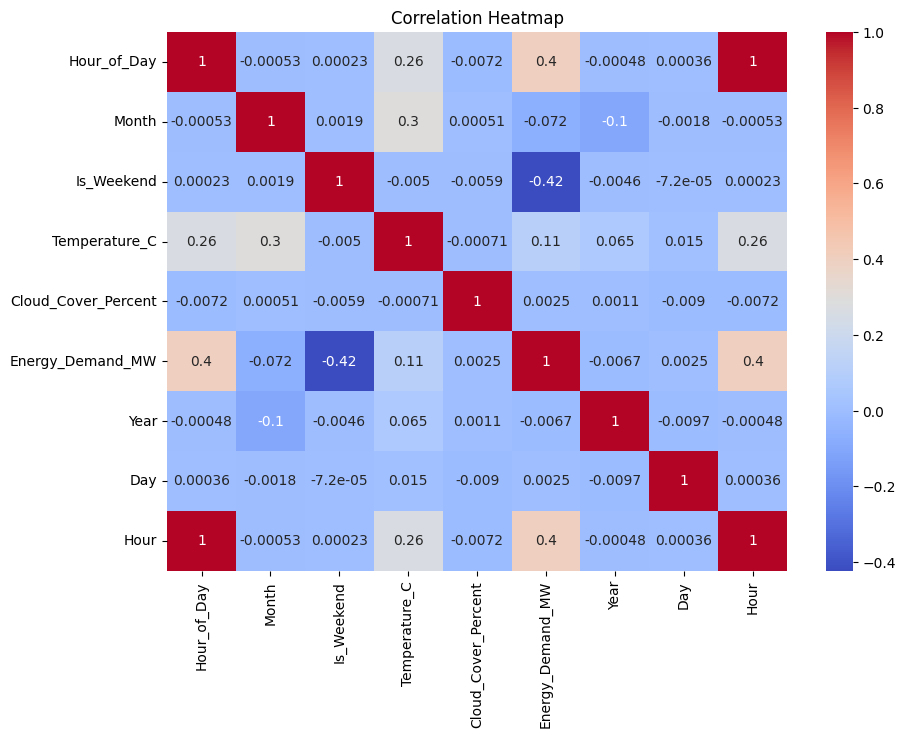

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

Task 18: Histogram

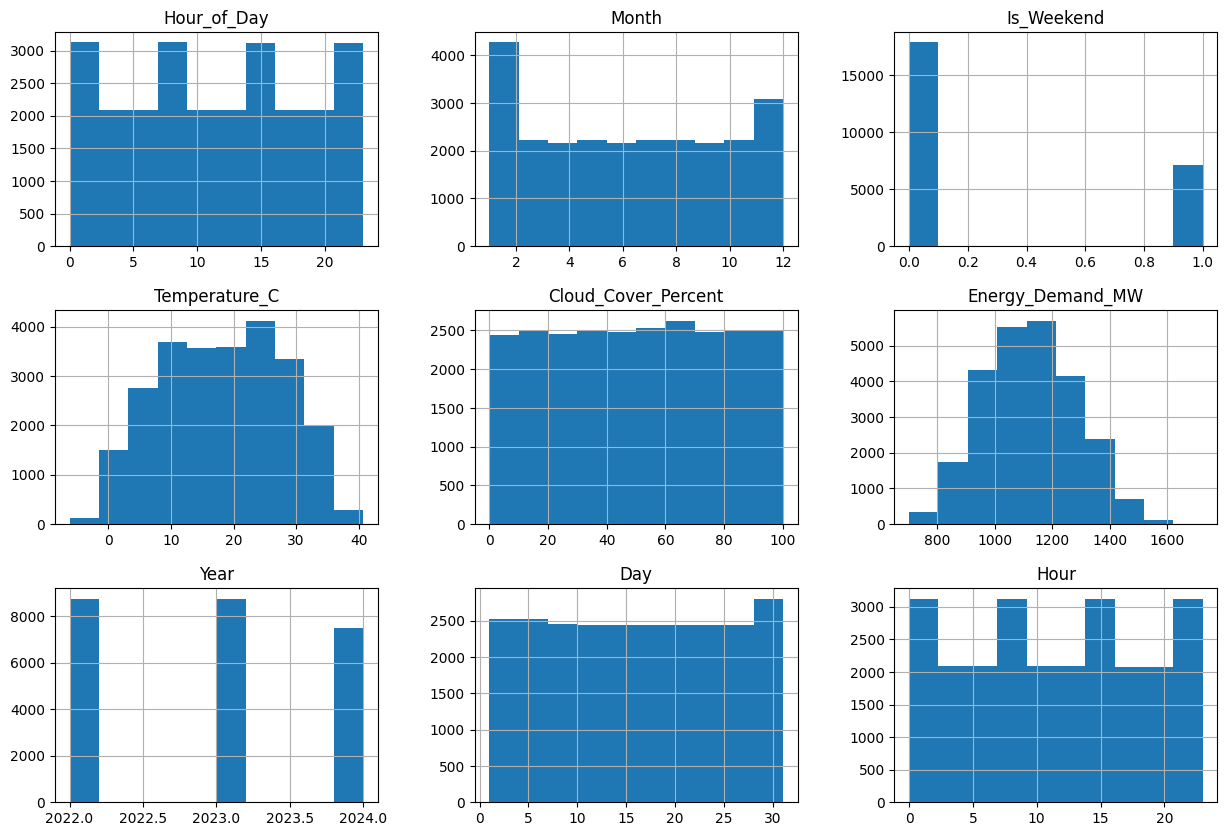

In [ ]:
df.hist(figsize=(15,10))

plt.show()

Task 19: Boxplots

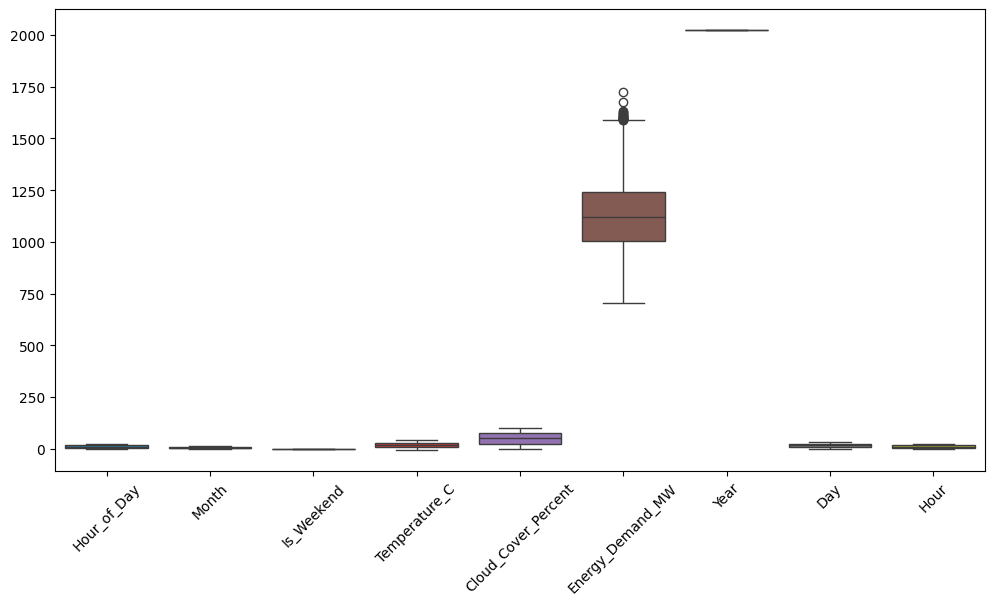

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

Task 20: Pair Plot

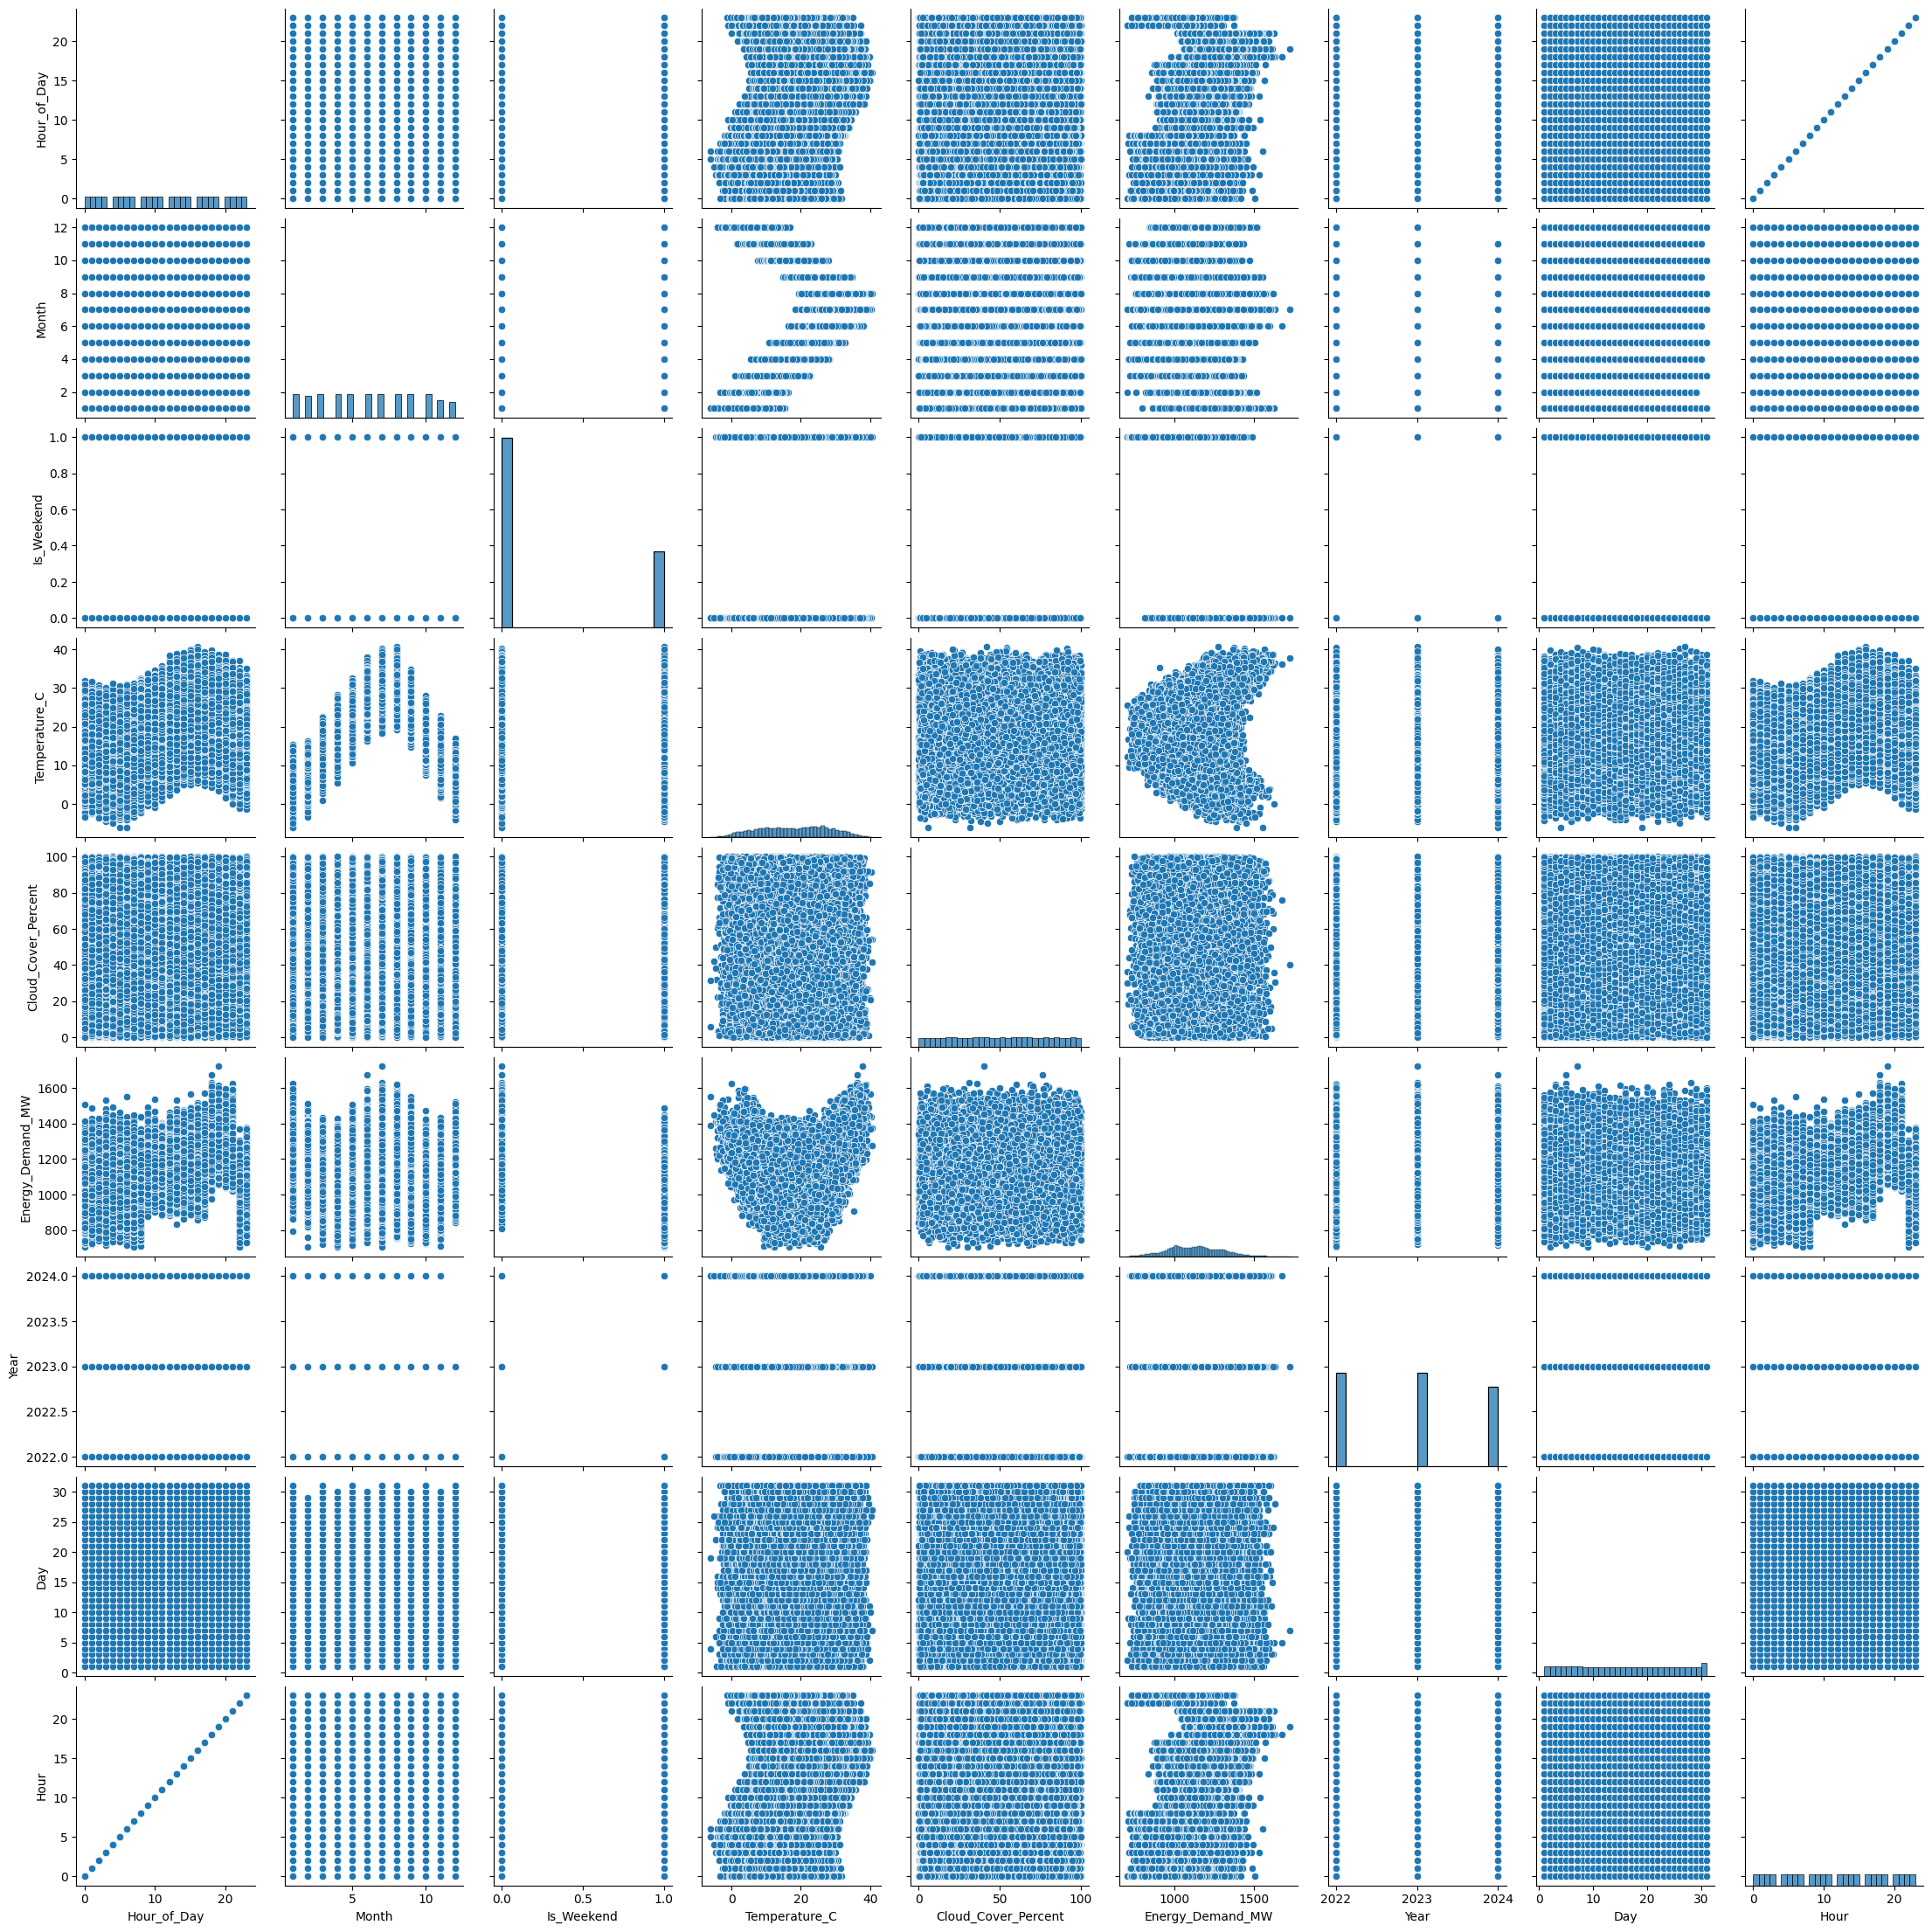

In [ ]:
sns.pairplot(df)

plt.show()

Task 21: Separate Features (X) and Target (y)*italicized text*

In [ ]:
# ==========================================
# TASK 23 : FEATURE SELECTION
# ==========================================

X = df.drop("Energy_Demand_MW", axis=1)

y = df["Energy_Demand_MW"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (25000, 8)
Target Shape : (25000,)


TASK 22 : FEATURE SCALING

In [ ]:
# ==========================================
# TASK 24 : FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

   Hour_of_Day     Month  Is_Weekend  Temperature_C  Cloud_Cover_Percent  \
0    -1.661073 -1.578048    1.579723      -1.837947            -1.665190   
1    -1.516600 -1.578048    1.579723      -1.837947            -0.013332   
2    -1.372127 -1.578048    1.579723      -1.806992            -0.851432   
3    -1.227653 -1.578048    1.579723      -1.910175             0.616113   
4    -1.083180 -1.578048    1.579723      -1.734763            -1.275699   

       Year       Day      Hour  
0 -1.179586 -1.660627 -1.661073  
1 -1.179586 -1.660627 -1.516600  
2 -1.179586 -1.660627 -1.372127  
3 -1.179586 -1.660627 -1.227653  
4 -1.179586 -1.660627 -1.083180  


Task 23: Train-Test Split

In [ ]:
# ==========================================
# TASK 23 : TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (20000, 8)
Testing Data : (5000, 8)


Task 24: Build Linear Regression Model
Explanation

Linear Regression predicts continuous numerical values.

In [ ]:
# ==========================================
# TASK 24 : BUILD MODEL
# ==========================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


Task 25: Model Coefficients
Explanation

Coefficients show how each feature affects the target variable.

In [ ]:
# ==========================================
# TASK 25 : MODEL COEFFICIENTS
# ==========================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

               Feature  Coefficient
0          Hour_of_Day    31.777484
1                Month   -13.068310
2           Is_Weekend   -66.876649
3        Temperature_C     4.236733
4  Cloud_Cover_Percent    -0.096333
5                 Year    -2.764282
6                  Day     0.835787
7                 Hour    31.777484


Task 26: Intercept
Explanation

Intercept is the predicted value when all feature values are zero.

In [ ]:
print("Intercept :", model.intercept_)

Intercept : 1125.1021587111347


Task 27: Prediction

In [ ]:
# ==========================================
# TASK 27 : PREDICTION
# ==========================================

y_pred = model.predict(X_test)

print(y_pred[:10])

[1086.87407407 1201.82311926 1258.3525404   987.05526525 1077.58694122
 1043.33508235 1249.44013919 1260.98399983  938.85003146 1214.24485862]


Task 28: Compare Actual vs Predicted

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(20))

    Actual    Predicted
0    965.9  1086.874074
1   1282.4  1201.823119
2   1306.2  1258.352540
3    838.8   987.055265
4   1114.9  1077.586941
5   1009.1  1043.335082
6   1559.9  1249.440139
7   1410.1  1260.984000
8    919.7   938.850031
9   1163.1  1214.244859
10  1228.4  1201.422302
11  1002.6  1285.350773
12  1281.7  1131.313990
13  1016.8  1071.337543
14   995.2  1275.277886
15  1376.9  1222.314353
16  1246.1  1206.748431
17   986.7  1136.965904
18  1203.6  1170.124743
19   906.4   927.050474


Task 29: Mean Absolute Error (MAE)

In [ ]:
# ==========================================
# TASK 29: MAE
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error :", mae)

Mean Absolute Error : 103.44692294205308


Task 30: Mean Squared Error (MSE)

In [ ]:
# ==========================================
# TASK 30 : MSE
# ==========================================

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error :", mse)

Mean Squared Error : 16694.77282734739


Task 31: Root Mean Squared Error (RMSE)

In [ ]:
# ==========================================
# TASK 31 : RMSE
# ==========================================

rmse = np.sqrt(mse)

print("Root Mean Squared Error :", rmse)

Root Mean Squared Error : 129.20825371216574


Task 32: R² Score

In [ ]:
# ==========================================
# TASK 32 : R2 SCORE
# ==========================================

r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.3445729651421343


Task 33: Scatter Plot (Actual vs Predicted)

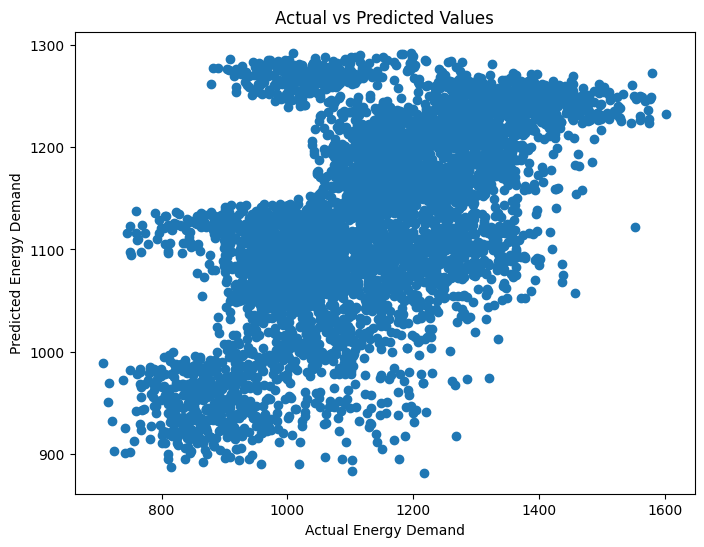

In [ ]:
# ==========================================
# TASK 33 : VISUALIZATION
# ==========================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Energy Demand")

plt.ylabel("Predicted Energy Demand")

plt.title("Actual vs Predicted Values")

plt.show()

Task 34: Residual Errors

In [ ]:
# ==========================================
# TASK 35 : RESIDUAL ERROR
# ==========================================

residual = y_test - y_pred

print(residual.head())

6868    -120.974074
24016     80.576881
9668      47.847460
13640   -148.255265
14018     37.313059
Name: Energy_Demand_MW, dtype: float64


Task 35: Residual Distribution

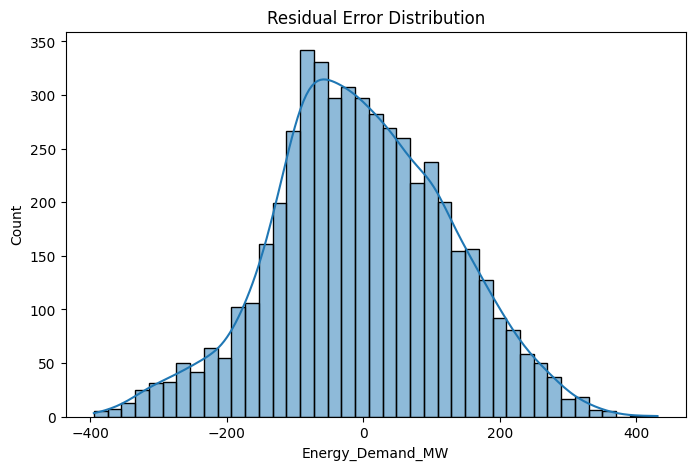

In [ ]:
# ==========================================
# TASK 35: RESIDUAL PLOT
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(residual, kde=True)

plt.title("Residual Error Distribution")

plt.show()



Task 36: Save the Model

In [ ]:
# ==========================================
# TASK 36 : SAVE MODEL
# ==========================================

joblib.dump(model, "2026-07-12_LinearRegression.pkl")

print("Linear Regression Model Saved Successfully")

Linear Regression Model Saved Successfully


Task 37: Load the Saved Model
Explanation

Load the saved model to verify that it was stored correctly.

In [ ]:
# ==========================================
# TASK 37 : LOAD MODEL
# ==========================================

loaded_model = joblib.load("2026-07-12_LinearRegression.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


Task 38: Predict Using Loaded Model

In [ ]:
loaded_prediction = loaded_model.predict(X_test)

print(loaded_prediction[:10])

[1086.87407407 1201.82311926 1258.3525404   987.05526525 1077.58694122
 1043.33508235 1249.44013919 1260.98399983  938.85003146 1214.24485862]


Final Insights

1. The dataset is suitable for a Linear Regression model because the target (Energy_Demand_MW) is continuous.

2. Missing values were handled using the mean of numerical columns.

3. Timestamp was converted into useful features (Year, Month, Day, Hour).

4. Correlation analysis helped identify relationships among variables.

5. Seaborn visualizations showed data distribution, feature relationships, and potential outliers.

6. StandardScaler was applied so all numerical features had the same scale.

7. The dataset was split into 80% training data and 20% testing data.

8. Linear Regression was trained to predict Energy Demand.

9. Model performance was evaluated using MAE, MSE, RMSE, and R² Score.

10. The trained model was saved using Joblib for future use.